In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [26]:
IMAGE_FOLDER = "pics"   # folder containing images
IMAGE_EXTS = (".jpg", ".png", ".jpeg")

In [29]:
lower_red1 = np.array([0, 150, 90])
upper_red1 = np.array([6, 255, 255])

lower_red2 = np.array([174, 150, 90])
upper_red2 = np.array([179, 255, 255])

kernel = np.ones((3,3), np.uint8)


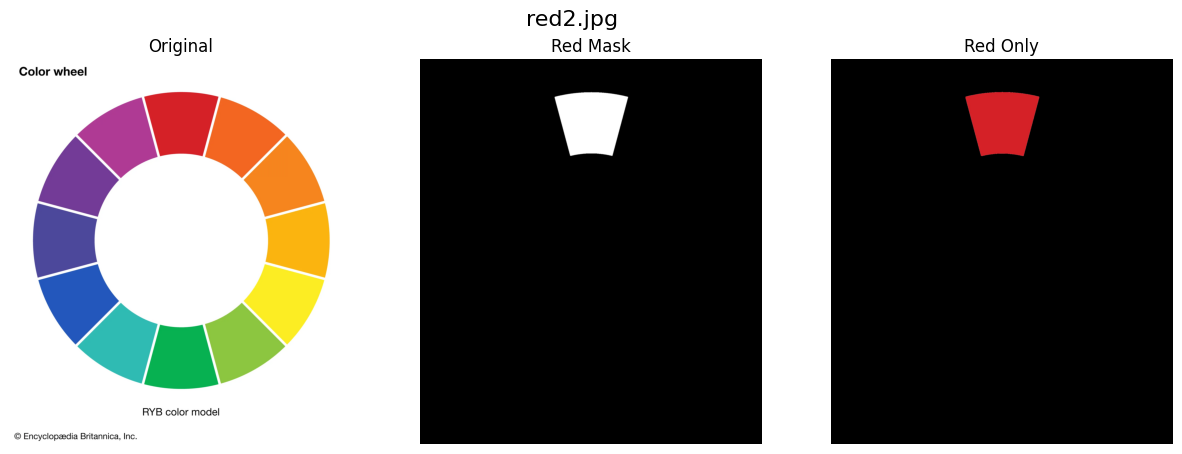

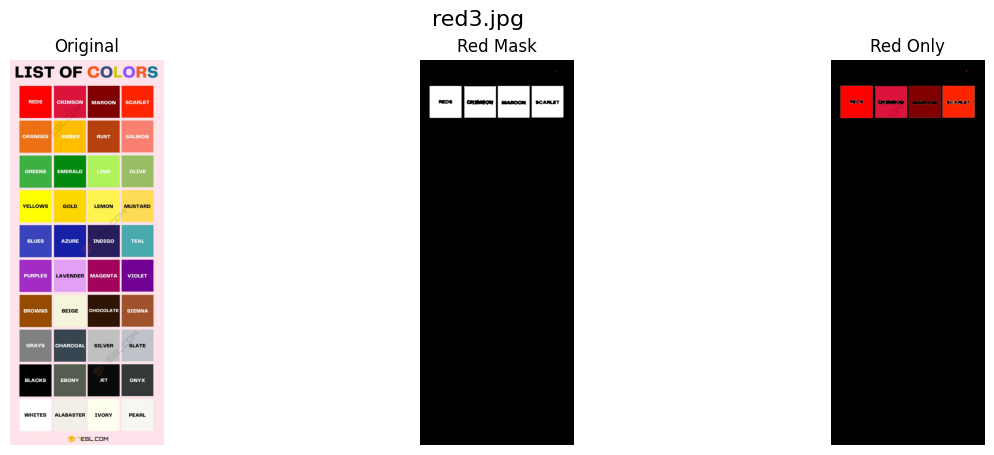

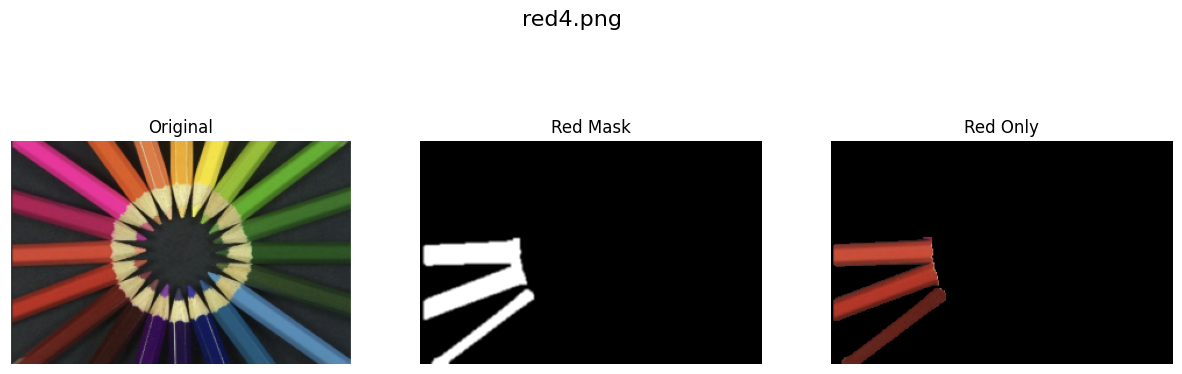

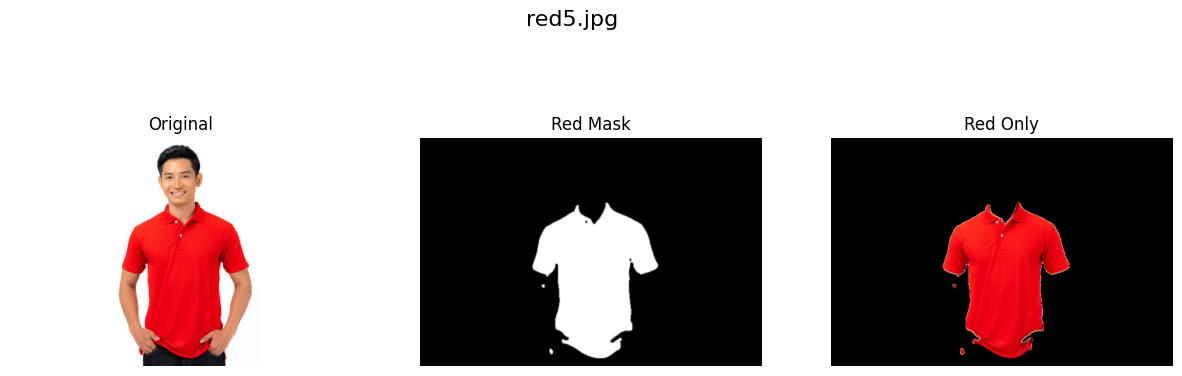

In [31]:
for file_name in sorted(os.listdir(IMAGE_FOLDER)):
    if not file_name.lower().endswith(IMAGE_EXTS):
        continue

    img_path = os.path.join(IMAGE_FOLDER, file_name)
    img = cv2.imread(img_path)

    if img is None:
        print(f"Could not read {file_name}")
        continue

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Blur
    img_blur = cv2.GaussianBlur(img, (7,7), 0)

    # Convert to HSV
    hsv = cv2.cvtColor(img_blur, cv2.COLOR_RGB2HSV)

    # Masks
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    red_mask = mask1 | mask2

    # Morphology
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel)
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_CLOSE, kernel)
    red_mask = cv2.GaussianBlur(red_mask, (3,3), 0)

    # Apply mask
    red_only = cv2.bitwise_and(img, img, mask=red_mask)

    # ==========================
    # DISPLAY
    # ==========================
    plt.figure(figsize=(15,5))
    plt.suptitle(file_name, fontsize=16)

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Red Mask")
    plt.imshow(red_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Red Only")
    plt.imshow(red_only)
    plt.axis("off")

    plt.show()